In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

In [2]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

In [3]:
X = df[['sepal length (cm)','sepal width (cm)']].values

In [4]:
scaler = StandardScaler()
X_scaler = scaler.fit_transform(X)

In [5]:
KMeans =KMeans(n_clusters=5,init='k-means++',random_state=42)
y_kmeans = KMeans.fit_predict(X_scaler)

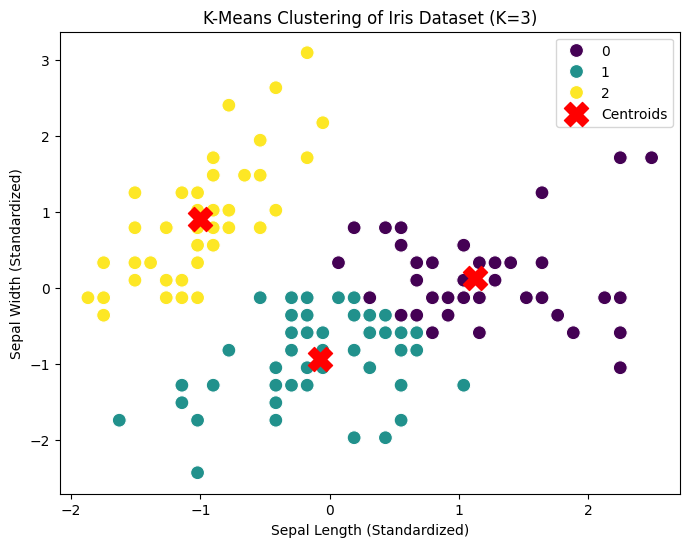

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# 1. Load dataset
iris = load_iris()
X = iris.data[:, :2]   # sirf 2 features (visualization ke liye)

# 2. Scale data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
y_kmeans = kmeans.fit_predict(X_scaled)

# 4. Plot
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    hue=y_kmeans,
    palette='viridis',
    s=100
)

# Centroids
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=300,
    c='red',
    marker='X',
    label='Centroids'
)

plt.xlabel('Sepal Length (Standardized)')
plt.ylabel('Sepal Width (Standardized)')
plt.title('K-Means Clustering of Iris Dataset (K=3)')
plt.legend()

plt.show()

In [7]:
import numpy as np

In [8]:

# Collect  all the data
X = np.array([
    [2,3,4],
    [3,5,6],
    [5,8,9],
    [6,9,11],
    [7,10,13]
    ])

In [9]:
# step 2 : compute mean value of each column

mean_X = np.mean(X, axis=0)
print(mean_X)

[4.6 7.  8.6]


In [10]:
# Step 2: Center the data
X_centered = X - mean_X

print("Mean:", mean_X)
print("Centered Data:\n", X_centered)

Mean: [4.6 7.  8.6]
Centered Data:
 [[-2.6 -4.  -4.6]
 [-1.6 -2.  -2.6]
 [ 0.4  1.   0.4]
 [ 1.4  2.   2.4]
 [ 2.4  3.   4.4]]


In [11]:
# Step 3 : Covariance matrix
cov_matrix = np.cov(X_centered, rowvar=False)

print("Covariance Matrix:\n", cov_matrix)

Covariance Matrix:
 [[ 4.3   6.    7.55]
 [ 6.    8.5  10.5 ]
 [ 7.55 10.5  13.3 ]]


In [12]:
# Step 4: Eigenvalues & Eigenvectors
eigen_values, eigen_vectors = np.linalg.eig(cov_matrix)

print("Eigenvalues:\n", eigen_values)
print("\nEigenvectors:\n", eigen_vectors)

Eigenvalues:
 [2.59637803e+01 5.52557327e-03 1.30694106e-01]

Eigenvectors:
 [[ 0.4066816   0.90812885  0.09955937]
 [ 0.56930735 -0.16669075 -0.80504865]
 [ 0.71449228 -0.38407836  0.58479449]]


In [13]:
# Step 5: Sort eigenvalues (descending)
sorted_indices = np.argsort(eigen_values)[::-1]

In [14]:
principal_components = eigen_vectors[:, sorted_indices]

print("Principal Components:\n", principal_components)

Principal Components:
 [[ 0.4066816   0.09955937  0.90812885]
 [ 0.56930735 -0.80504865 -0.16669075]
 [ 0.71449228  0.58479449 -0.38407836]]


In [15]:
# Step 5: Select top 2 principal components
PC_2 = eigen_vectors[:, :2]

# Step 6: Transform data (3D → 2D)
X_transformed_2 = np.dot(X_centered, PC_2)

In [16]:
# Output result
print("Transformed Data (3 to 2):")
print(X_transformed_2)

Transformed Data (3 to 2):
[[-6.62126605  0.07238845]
 [-3.64698519 -0.12102092]
 [ 1.0177769   0.04292944]
 [ 3.42275041  0.01621082]
 [ 5.82772392 -0.01050779]]


In [17]:
# import libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [18]:
# load dataset

df = pd.read_csv("./Datasets/winequality-red.csv")
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1591,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1592,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1593,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1594,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [19]:
df['quality'].unique()

array([5, 6, 7, 4, 8, 3])

In [20]:
X=df.iloc[:,:-1].values
y=df.iloc[:,-1].values

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

In [22]:
# feature scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test= scaler.transform(X_test)



In [23]:
# Apply PCA
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)

In [24]:
pip install pyclustering

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyclustering.cluster.kmedoids import kmedoids
from pyclustering.utils import distance_metric, type_metric
from sklearn import datasets
from sklearn.preprocessing import StandardScaler

In [34]:
# load  the wine datasets
wine = datasets.load_wine()


In [35]:
## convert the data into dataframe for better understanding
wine= pd.DataFrame(wine.data, columns=wine.feature_names)


In [29]:
wine.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [36]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
dtypes: fl

In [37]:
# standerdize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(wine)

In [ ]:
# initilize the medoids (can be randomly chose or specified)
# Here we choose the first three data points as initial medoids )

initial_medoids = [0, 1,2]  

In [40]:
import random
initial_medoids = random.sample(range(len(X_scaled)), 3)

In [42]:
# create k-medoids instance 
metric = distance_metric(type_metric.EUCLIDEAN)

# euclidean distance metric 

kmedoids_instance = kmedoids(X_scaled, initial_medoids, metric=metric)

In [43]:
# perform the clustering process
kmedoids_instance.process()

In [44]:
# get the  results clusters and medoids
clusters = kmedoids_instance.get_clusters()
medoids = kmedoids_instance.get_medoids()

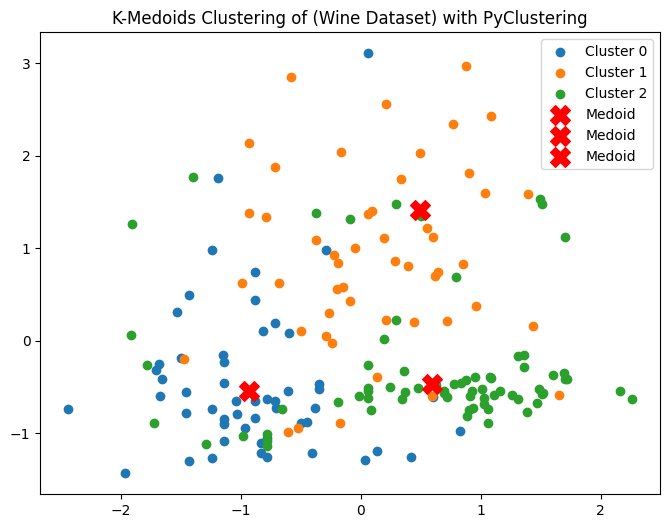

In [48]:
# plot the results
plt.figure(figsize=(8, 6))
for cluster in clusters:
    plt.scatter(X_scaled[cluster, 0], X_scaled[cluster, 1], label=f'Cluster {clusters.index(cluster)}')

# marks the medoids in red 

for medoid in medoids:
    plt.scatter(X_scaled[medoid, 0], X_scaled[medoid, 1], s=200, c='red', marker='X', label='Medoid')

plt.title('K-Medoids Clustering of (Wine Dataset) with PyClustering')
  

plt.legend()
plt.show()
